# PASTORS + TabPFN (Google Colab)

**Before running:** Runtime → Change runtime type → **GPU (T4)**.

Upload to a Drive folder (e.g. `MyDrive/pastors/`) keeping this structure:
```
pastors/
  helpers/                         (all .py)
  data/geospatial/oman_processed_closed.geojson
  data/geospatial/validation_processed_closed.geojson
  data/satellite/fused_spot_s2_oman.tif (+ .json + _metadata.json)
  output/baresoil_mask_oman.tif        (only for raster prediction)
  utils/tabpfn_token.json          {"token": "<your_tabpfn_token>"}
```
Set `BASE` below to that folder.

In [1]:
!pip install -q tabpfn-client rasterio geopandas composition_stats

In [2]:
import os, sys
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/pastors'     # <-- your Drive folder
os.chdir(BASE); sys.path.insert(0, BASE)

# --- TabPFN cloud client: token read from a git-ignored JSON file ---
import json
from tabpfn_client import set_access_token

TOKEN_PATH = os.path.join(BASE, 'utils', 'tabpfn_token.json')
try:
    with open(TOKEN_PATH) as f:
        TABPFN_TOKEN = json.load(f)['token']
except FileNotFoundError:
    raise SystemExit(
        f'Missing {TOKEN_PATH}. Create it locally (never commit it) as:\n'
        '  {"token": "<your_tabpfn_token>"}'
    )

set_access_token(TABPFN_TOKEN)
print("TabPFN client authenticated")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TabPFN client authenticated


In [3]:
import os
import numpy as np, pandas as pd, geopandas as gpd
from helpers.prepare_validation import prepare_validation
from helpers.background_removal import background_removal
from helpers.load_satellite_data import load_satellite_data
from helpers.symmetric_balances import group_balance
from helpers.dendro_groups import compositional_groups
from helpers.spatial_cv import (make_spatial_groups, spatial_cv_predict,
                                regression_metrics, agreement_metrics,
                                resolve_threshold)
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr, spearmanr
from tabpfn_client import TabPFNRegressor

# ── Config ──
dataset   = "kenya" #"kenya", "oman"
satellite = f"fused_spot_s2_{dataset}"
buffer    = 500
EXCLUDE_VAL_IDS = [3, 5]
SHARPEN_SWIR          = False
RESTRICT_TRAINING     = True
USE_GLOBAL_BACKGROUND = False
AUTO_GROUPS       = True
if dataset == "oman":
    ACTIVE_SITES        = ["S4","S7","S10"]
    GROUP_EXCLUDE_SITES = ["S11","S12"]
    GROUP_TYPE_PREFIX   = "CORRAL"
else:  # kenya
    ACTIVE_SITES        = ["E2","E4","E7","E9"]   # pick your enclosure sites
    GROUP_EXCLUDE_SITES = []
    GROUP_TYPE_PREFIX   = "COR"   # matches both CORAL and CORRAL

# fallback manual groups if AUTO_GROUPS=False
MARKERS_MANUAL    = ['P','Cl','K'] #active: 'P','Cl','K', #aband:'P','Sr','Zn', 'Mn'
NATBG_MANUAL      = ['Si', 'Al', 'Fe', 'Ti', 'Mg']

# ── Evaluation parity with pastors.ipynb (XGBoost) ──
# Score TabPFN with the SAME leave-site-out spatial CV, threshold and metrics
# so the two models are directly comparable (not a leaky random split).
AGREEMENT_THRESHOLD = "antimode" #0.0     # depleted (<thr) / elevated (>thr); 0.0 or "antimode"
CV_MAX_FOLDS = None           # None = leave-site-out (exact parity); int = GroupKFold(n)
                              #   -> set e.g. 5 to cut TabPFN cloud calls (loses split parity)

In [4]:

# ── Load, background-remove, detect groups, build balance ──
dataset_path = f"./data/geospatial/{dataset}_processed_closed.geojson"
gdf  = gpd.read_file(dataset_path) #_active, _imputed

VAL_PATH = "./data/geospatial/validation_processed_closed.geojson"
HAS_VAL  = (dataset == "oman") and os.path.exists(VAL_PATH)

if HAS_VAL:
    gval = gpd.read_file(VAL_PATH)
    gval["Serial"] = gval["Serial"].astype(str)
    gdf, gval_bg, shared = prepare_validation(gdf, gval, restrict_training=RESTRICT_TRAINING)
else:
    gval_bg = None
    print("No validation set — skipping external validation")

if AUTO_GROUPS:
    grp = compositional_groups(dataset_path,
            include_sites=ACTIVE_SITES, exclude_sites=GROUP_EXCLUDE_SITES,
            type_prefix=GROUP_TYPE_PREFIX, exclude_parts=("Res",))
    markers, natural_bgk = grp["markers"], grp["natural_bgk"]
else:
    markers, natural_bgk = MARKERS_MANUAL, NATBG_MANUAL
print("markers:", markers, "| natural_bgk:", natural_bgk)

gbk = background_removal(gdf, buffer_distance=buffer, use_global_background=USE_GLOBAL_BACKGROUND)
df  = load_satellite_data(satellite, gbk, sharpen_swir=SHARPEN_SWIR)
df["balance"] = group_balance(df, markers, natural_bgk)

if HAS_VAL:
    gval_bk = background_removal(gval_bg, buffer_distance=buffer, use_global_background=USE_GLOBAL_BACKGROUND)
    gval_bk = gval_bk.loc[gval_bk.index.intersection(gval_bg["Serial"])]
    dfv = load_satellite_data(satellite, gval_bk, sharpen_swir=SHARPEN_SWIR)
    dfv["balance"] = group_balance(dfv, markers, natural_bgk)

No validation set — skipping external validation
markers: ['Mg', 'P', 'K', 'Ca', 'Mn', 'Zn', 'Rb', 'Sr', 'Zr'] | natural_bgk: ['Al', 'Si', 'Ti', 'Fe', 'Y', 'Ba']
✅ Background removal complete for 20 sites.
Loading raster: ./data/satellite/fused_spot_s2_kenya.tif
  aggregated 23 multi-sample pixels
  added NDVI, SAVI
  added BSI, NDMI, Clay_Index
  added NDWI, Calcite_Index
  output: 1603 rows x 37 cols (16 elements + 14 bands + 7 indices)
✅ Satellite data integration complete
✅ Completed balance comparing between marker-elements and natural-background.


In [5]:
# ── Feature matrix ──
# 'Emb_' included for parity with pastors.ipynb (harmless if no embedding bands).
sat_kw = ("Band_","Drag_","S2_","SPOT_","Maxar_","Emb_")
idx_kw = ("NDVI","SAVI","BSI","NDMI","NDWI","MSAVI","Clay","Calcite","Iron","EVI","NBR")
feature_cols = [c for c in df.columns if c.startswith(sat_kw) or any(c.startswith(k) for k in idx_kw)]
X = df[feature_cols].values; y = df["balance"].values

# Site label per pixel -> leave-site-out spatial CV groups (same as XGBoost).
df["Site"] = gdf.set_index("Serial").loc[df.index, "Site"].values
groups_all, _ = make_spatial_groups(sites=df["Site"].values, strategy="site")

print(f"features: {len(feature_cols)} | train samples: {len(y)} | "
      f"sites: {len(np.unique(groups_all))} | val: {len(dfv) if HAS_VAL else 0}")
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

features: 21 | train samples: 1603 | sites: 20 | val: 0


In [6]:
# ── Utilities: safe metrics saving + run metadata (Fix 5) ─────────────────
import json as _json, datetime as _dt
try:
    import importlib.metadata as _im
except ImportError:
    import importlib_metadata as _im

def save_metrics_row(path, row, keys=("model", "eval", "dataset")):
    """Append/replace ONE row keyed by (model, eval, dataset) WITHOUT wiping
    other rows (old cell 7 overwrote the whole CSV and deleted the external
    row). Saves ALL columns passed in `row`, incl. RMSE/MAE/Pearson."""
    prev = pd.read_csv(path) if os.path.exists(path) else pd.DataFrame()
    if not prev.empty:
        m = np.ones(len(prev), dtype=bool)
        for k in keys:
            if k in prev.columns:
                m &= (prev[k].astype(str) == str(row.get(k)))
        prev = prev[~m]
    out = pd.concat([prev, pd.DataFrame([row])], ignore_index=True)
    os.makedirs(os.path.dirname(path), exist_ok=True)
    out.to_csv(path, index=False)
    return out

def log_run_metadata(extra=None):
    """Pin what CAN be pinned. TabPFN cloud is not seedable/version-pinnable
    client-side -> record client version + date so numbers are attributable."""
    meta = {"date": _dt.datetime.now().isoformat(timespec="seconds"),
            "dataset": dataset, "satellite": satellite, "buffer": buffer,
            "tabpfn_n_estimators": 8,
            "agreement_threshold": AGREEMENT_THRESHOLD,
            "cv_max_folds": CV_MAX_FOLDS,
            "exclude_val_ids": EXCLUDE_VAL_IDS,
            "restrict_training": RESTRICT_TRAINING,
            "sharpen_swir": SHARPEN_SWIR,
            "n_features": len(feature_cols), "feature_cols": feature_cols}
    for pkg in ("tabpfn-client", "scikit-learn", "numpy", "pandas",
                "geopandas", "rasterio", "scipy"):
        try:
            meta[pkg] = _im.version(pkg)
        except Exception:
            meta[pkg] = "n/a"
    if extra:
        meta.update(extra)
    os.makedirs("./output", exist_ok=True)
    p = f"./output/{dataset}_run_metadata.json"
    with open(p, "w") as f:
        _json.dump(meta, f, indent=2, default=str)
    print("run metadata ->", p)
    return meta


# ── Evaluation registry (feeds the single summary figure at the end) ──────
# Each evaluation registers its (true, predicted) pair once; the summary cell
# then draws ONE two-panel figure and ONE compact table from the registry.
EVALS = {}

def register_eval(label, y_true, y_pred, thr=0.0, note=""):
    EVALS[label] = {"true": np.asarray(y_true, float),
                    "pred": np.asarray(y_pred, float),
                    "thr": float(thr), "note": note}
    print(f"  [registered for summary] {label}  n={len(EVALS[label]['true'])}")

# Set False to skip the per-evaluation scatter plots (they are supplementary:
# they show MAGNITUDE, while the claim in the paper is about RANKING).
SUPPLEMENTARY_PLOTS = False

In [7]:
reg = TabPFNRegressor(n_estimators=8)
reg.fit(X_tr, y_tr)

def metrics(yt, yp):
    return dict(R2=round(r2_score(yt,yp),3),
                RMSE=round(np.sqrt(mean_squared_error(yt,yp)),3),
                MAE=round(mean_absolute_error(yt,yp),3),
                Pearson=round(pearsonr(yt,yp)[0],3),
                Spearman=round(spearmanr(yt,yp)[0],3))
_p_int = reg.predict(X_te)
print("Internal 20% test:", metrics(y_te, _p_int))
print("NOTE: random 80/20 shares sites between train/test -> this measures "
      "WITHIN-SITE INTERPOLATION (the deployment case for mapping this scene), "
      "not transfer to an unseen site.")
register_eval("Internal 80/20", y_te, _p_int,
              thr=resolve_threshold(AGREEMENT_THRESHOLD, y_tr),
              note="within-site interpolation")

00:00 Fitting... \

00:05 Fitting... Done!
00:00 Predicting... \

00:02 Predicting... Done!
Internal 20% test: {'R2': 0.311, 'RMSE': np.float64(0.229), 'MAE': 0.127, 'Pearson': np.float64(0.559), 'Spearman': np.float64(0.528)}
NOTE: random 80/20 shares sites between train/test -> this measures WITHIN-SITE INTERPOLATION (the deployment case for mapping this scene), not transfer to an unseen site.
  [registered for summary] Internal 80/20  n=321


In [8]:
# ── Reusable eval plots (both figures) — mirrors pastors.ipynb, works on ANY eval set ──
import matplotlib.pyplot as plt

def plot_eval(y_true, y_pred, dataset, eval_label, thr,
              out_dir="./output", model_tag="tabpfn", index=None):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    df_eval = pd.DataFrame({"true": y_true, "predicted": y_pred},
                           index=index if index is not None else range(len(y_true)))
    df_eval["residual"] = df_eval["predicted"] - df_eval["true"]
    yt, yp, res = df_eval["true"].values, df_eval["predicted"].values, df_eval["residual"].values

    r2, rmse = r2_score(yt, yp), np.sqrt(mean_squared_error(yt, yp))
    mae, pear, spear = mean_absolute_error(yt, yp), pearsonr(yt, yp)[0], spearmanr(yt, yp)[0]
    lim  = [min(yt.min(), yp.min()) - 0.1, max(yt.max(), yp.max()) + 0.1]
    slug = eval_label.lower().replace(" ", "_")

    # Fig 1: predicted vs true, coloured by residual
    fig, ax = plt.subplots(figsize=(9, 8))
    vmax = max(abs(res.min()), abs(res.max()))
    sc = ax.scatter(yt, yp, c=res, cmap="RdYlBu_r", vmin=-vmax, vmax=vmax,
                    s=60, alpha=0.85, edgecolor="black", linewidth=0.5, zorder=3)
    cb = plt.colorbar(sc); cb.set_label("Residual (Pred − True)", rotation=270, labelpad=15)
    if len(df_eval) <= 80:
        for idx, r in df_eval.iterrows():
            ax.text(r["true"] + 0.015, r["predicted"] + 0.015, str(idx), fontsize=8, alpha=0.8, zorder=4)
    ax.plot(lim, lim, "r--", lw=1.5, label="Ideal (1:1)", zorder=2)
    ax.text(0.05, 0.95, (f"n = {len(df_eval)}\n$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}\n"
            f"MAE = {mae:.3f}\nPearson r = {pear:.3f}\nSpearman ρ = {spear:.3f}"),
            transform=ax.transAxes, fontsize=11, va="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))
    ax.set_xlabel("Measured/True Balance", fontsize=12, fontweight="bold")
    ax.set_ylabel("Predicted Balance", fontsize=12, fontweight="bold")
    ax.set_title(f"{dataset.title()} — {eval_label} (TabPFN): Predicted vs True", fontsize=14, pad=15)
    ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{out_dir}/{dataset}_{slug}_pred_vs_true_{model_tag}.png", dpi=200, bbox_inches="tight")
    plt.show()

    # Fig 2: elevated/depleted agreement
    agr = agreement_metrics(yt, yp, threshold=thr)
    ok  = (yt > thr) == (yp > thr)
    fig, ax = plt.subplots(figsize=(7.5, 7))
    ax.axhline(thr, color="grey", ls=":", lw=1); ax.axvline(thr, color="grey", ls=":", lw=1)
    ax.scatter(yt[ok],  yp[ok],  c="seagreen", s=55, edgecolor="k", lw=.4, label="correct side", zorder=3)
    ax.scatter(yt[~ok], yp[~ok], c="crimson",  s=55, edgecolor="k", lw=.4, label="wrong side", zorder=3)
    ax.plot(lim, lim, "r--", lw=1.2, zorder=2)
    ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
    ax.set_xlabel("Measured balance"); ax.set_ylabel("Predicted balance")
    ax.set_title(f"{dataset.title()} — {eval_label} (TabPFN): elevated/depleted agreement\n"
                 f"AUC={agr['AUC']:.2f}  bal.acc={agr['balanced_acc']:.2f}  MCC={agr['MCC']:.2f}")
    ax.legend(loc="lower right"); plt.tight_layout()
    plt.savefig(f"{out_dir}/{dataset}_{slug}_agreement_{model_tag}.png", dpi=200, bbox_inches="tight")
    plt.show()
    return df_eval

# (definition only — the strict-CV cell below calls plot_eval on its own
#  oof_true/oof_pred arrays; the old vmask/oof_tab variables no longer exist)

In [9]:
# ── STRICT leave-site-out CV (Fix 1): target re-derived per fold ──────────
# Closes the target-construction leak: compositional marker groups are derived
# INSIDE each fold from training sites only (like fitting a scaler on train),
# then used to compute the balance for BOTH train and held-out rows. The
# agreement threshold is resolved from training-fold y only (guards the
# latent "antimode" leak). Per-fold metrics are PRIMARY; pooled is secondary.
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, matthews_corrcoef

GEO_PATH   = f"./data/geospatial/{dataset}_processed_closed.geojson"
sites_arr  = df["Site"].values
uniq_sites = np.unique(sites_arr)

oof_pred = np.full(len(df), np.nan)
oof_true = np.full(len(df), np.nan)
oof_lt   = np.zeros(len(df), dtype=bool)   # true label (elevated) per fold thr
oof_lp   = np.zeros(len(df), dtype=bool)   # predicted label
fold_rows, group_log = [], []

for s in uniq_sites:
    te = np.where(sites_arr == s)[0]
    tr = np.where(sites_arr != s)[0]

    # 1) fold-specific marker groups from TRAINING sites only
    try:
        g = compositional_groups(GEO_PATH,
                include_sites=[a for a in ACTIVE_SITES if a != s],
                exclude_sites=list(GROUP_EXCLUDE_SITES) + [s],
                type_prefix=GROUP_TYPE_PREFIX, exclude_parts=("Res",))
        mk, bgk, fb = g["markers"], g["natural_bgk"], False
    except Exception as e:
        # derivation impossible without this site (e.g. it is an ACTIVE site
        # and too few remain) -> fall back to full-data groups, FLAGGED as a
        # partial leak for this fold. Inspect these folds.
        mk, bgk, fb = markers, natural_bgk, True
    group_log.append({"site": s, "markers": ",".join(mk),
                      "natural_bgk": ",".join(bgk), "fallback": fb,
                      "same_as_full": set(mk) == set(markers)
                                      and set(bgk) == set(natural_bgk)})

    # 2) fold-specific target (train + held-out, SAME train-derived definition)
    y_tr = np.asarray(group_balance(df.iloc[tr], mk, bgk), dtype=float)
    y_te = np.asarray(group_balance(df.iloc[te], mk, bgk), dtype=float)

    # 3) fit / predict
    mdl = TabPFNRegressor(n_estimators=8)
    mdl.fit(X[tr], y_tr)
    p = np.asarray(mdl.predict(X[te]), dtype=float)

    oof_pred[te], oof_true[te] = p, y_te
    thr_f = resolve_threshold(AGREEMENT_THRESHOLD, y_tr)   # TRAIN ONLY
    oof_lt[te] = y_te > thr_f
    oof_lp[te] = p    > thr_f

    fm = regression_metrics(y_te, p)
    fold_rows.append({"site": s, "n": len(te), "thr": round(float(thr_f), 3), **fm})
    print(f"  fold {s:>6}: n={len(te):4d}  R2={fm['R2']:7.3f}  "
          f"Spearman={fm['Spearman']:6.3f}" + ("  [FALLBACK GROUPS]" if fb else ""))

folds = pd.DataFrame(fold_rows)
gstab = pd.DataFrame(group_log)

n_same = int(gstab["same_as_full"].sum())
print(f"\nMarker-group stability: {n_same}/{len(gstab)} folds identical to "
      f"full-data derivation" +
      (f"  |  {int(gstab.fallback.sum())} FALLBACK fold(s) — partial leak, inspect"
       if gstab["fallback"].any() else "  |  no fallbacks"))

vm = np.isfinite(oof_pred) & np.isfinite(oof_true)
pooled = regression_metrics(oof_true[vm], oof_pred[vm])
auc  = roc_auc_score(oof_lt[vm], oof_pred[vm]) if 0 < oof_lt[vm].mean() < 1 else np.nan
bacc = balanced_accuracy_score(oof_lt[vm], oof_lp[vm])
mcc  = matthews_corrcoef(oof_lt[vm], oof_lp[vm])

print("\nPER-FOLD R² (PRIMARY):  median={:.3f}  IQR=[{:.3f}, {:.3f}]  "
      "mean={:.3f}±{:.3f}".format(folds.R2.median(),
      folds.R2.quantile(.25), folds.R2.quantile(.75),
      folds.R2.mean(), folds.R2.std()))
print("POOLED (secondary — inflated by between-site spread): "
      + "  ".join(f"{k}={v:.3f}" for k, v in pooled.items()))
print(f"POOLED agreement: AUC={auc:.3f}  bal_acc={bacc:.3f}  MCC={mcc:.3f}")

folds.to_csv(f"./output/{dataset}_tabpfn_strict_cv_folds.csv", index=False)
gstab.to_csv(f"./output/{dataset}_tabpfn_fold_groups.csv", index=False)

row = {"model": "TabPFN", "eval": "spatial_cv_strict", "dataset": dataset,
       "cv": "LeaveOneGroupOut(strict)", "thr": round(float(folds.thr.iloc[0]), 3),
       **{k: round(float(v), 3) for k, v in pooled.items()},
       "AUC": round(float(auc), 3), "bal_acc": round(float(bacc), 3),
       "MCC": round(float(mcc), 3),
       "R2_fold_median": round(float(folds.R2.median()), 3),
       "R2_fold_mean": round(float(folds.R2.mean()), 3),
       "R2_fold_std": round(float(folds.R2.std()), 3), "n_folds": len(folds)}
save_metrics_row(f"./output/{dataset}_tabpfn_metrics.csv", row)
print("saved full metrics row -> ./output/{}_tabpfn_metrics.csv".format(dataset))

# spatial-CV OOF plots (same two figures) on the strict predictions
thr0 = resolve_threshold(AGREEMENT_THRESHOLD, oof_true[vm])  # display only
register_eval("Site LOGO", oof_true[vm], oof_pred[vm], thr=thr0,
              note="unseen site — transfer lower bound")
if SUPPLEMENTARY_PLOTS:
    plot_eval(oof_true[vm], oof_pred[vm], dataset, "Spatial CV strict", thr0,
              model_tag="tabpfn")


✅ Completed balance comparing between marker-elements and natural-background.
✅ Completed balance comparing between marker-elements and natural-background.
00:00 Fitting... \

00:05 Fitting... Done!
00:00 Predicting... \

00:02 Predicting... Done!
  fold     A1: n=  72  R2= -0.133  Spearman= 0.268
✅ Completed balance comparing between marker-elements and natural-background.
✅ Completed balance comparing between marker-elements and natural-background.
00:00 Fitting... \

00:05 Fitting... Done!
00:00 Predicting... \

00:02 Predicting... Done!
  fold    A10: n=  62  R2= -0.152  Spearman= 0.050
✅ Completed balance comparing between marker-elements and natural-background.
✅ Completed balance comparing between marker-elements and natural-background.
00:00 Fitting... \

...

00:02 Predicting... Done!
  fold     E7: n=  62  R2=  0.240  Spearman= 0.171
✅ Completed balance comparing between marker-elements and natural-background.
✅ Completed balance comparing between marker-elements and natural-background.
00:00 Fitting... \

00:05 Fitting... Done!
00:00 Predicting... \

00:02 Predicting... Done!
  fold     E8: n=  96  R2= -0.605  Spearman= 0.181
✅ Completed balance comparing between marker-elements and natural-background.
✅ Completed balance comparing between marker-elements and natural-background.
00:00 Fitting... \

00:05 Fitting... Done!
00:00 Predicting... \

00:02 Predicting... Done!
  fold     E9: n= 140  R2=  0.014  Spearman= 0.062

Marker-group stability: 18/20 folds identical to full-data derivation  |  no fallbacks

PER-FOLD R² (PRIMARY):  median=-0.142  IQR=[-0.437, -0.042]  mean=-0.398±0.656
POOLED (secondary — inflated by between-site spread): R2=0.125  RMSE=0.381  MAE=0.173  Pearson=0.360  Spearman=0.360
POOLED agreement: AUC=0.189  bal_acc=0.894  MCC=0.811
saved full metrics row -> ./output/kenya_tabpfn_metrics.csv
  [registered for summary] Site LOGO  n=1603


SITE LEVEL (n=20 sites)
  site-mean Pearson : 0.755  CI95 [0.265, 0.911]
  site-mean Spearman: 0.528  CI95 [0.078, 0.815]
  per-fold R2 mean  : -0.398  CI95 [-0.700, -0.145]


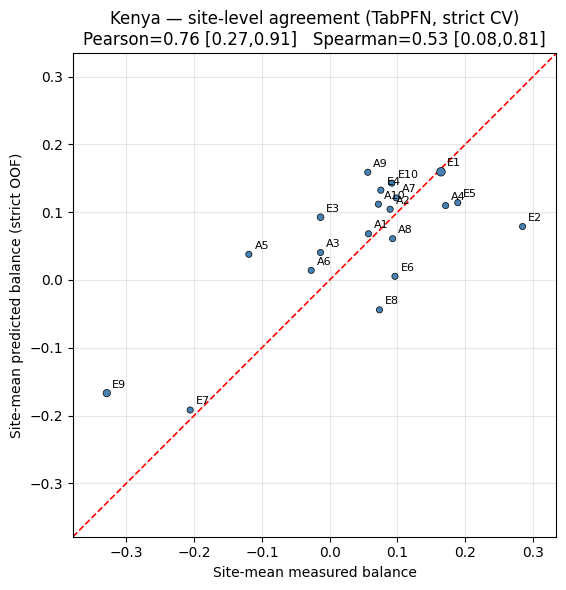

run metadata -> ./output/kenya_run_metadata.json


{'date': '2026-07-20T13:18:04',
 'dataset': 'kenya',
 'satellite': 'fused_spot_s2_kenya',
 'buffer': 500,
 'tabpfn_n_estimators': 8,
 'agreement_threshold': 'antimode',
 'cv_max_folds': None,
 'exclude_val_ids': [3, 5],
 'restrict_training': True,
 'sharpen_swir': False,
 'n_features': 21,
 'feature_cols': ['SPOT_red',
  'SPOT_green',
  'SPOT_blue',
  'SPOT_nir',
  'S2_B2_blue',
  'S2_B3_green',
  'S2_B4_red',
  'S2_B5_rededge1',
  'S2_B6_rededge2',
  'S2_B7_rededge3',
  'S2_B8_nir',
  'S2_B8A_nir08',
  'S2_B11_swir16',
  'S2_B12_swir22',
  'NDVI',
  'SAVI',
  'BSI',
  'NDMI',
  'Clay_Index',
  'NDWI',
  'Calcite_Index'],
 'tabpfn-client': '0.3.3',
 'scikit-learn': '1.6.1',
 'numpy': '2.0.2',
 'pandas': '2.2.2',
 'geopandas': '1.1.4',
 'rasterio': '1.5.0',
 'scipy': '1.16.3',
 'strict_cv_n_folds': 20,
 'fold_sites': ['A1',
  'A10',
  'A2',
  'A3',
  'A4',
  'A5',
  'A6',
  'A7',
  'A8',
  'A9',
  'E1',
  'E10',
  'E2',
  'E3',
  'E4',
  'E5',
  'E6',
  'E7',
  'E8',
  'E9']}

In [10]:
# ── Site-level reporting + bootstrap CIs (Fix 2) ──────────────────────────
# Pixels within a site are pseudo-replicates: the honest experimental unit is
# the SITE. Report (a) per-fold R² distribution and (b) site-mean agreement,
# both with bootstrap CIs, as the headline numbers.
rng = np.random.default_rng(42)

site_df = (pd.DataFrame({"site": sites_arr[vm],
                         "true": oof_true[vm], "pred": oof_pred[vm]})
           .groupby("site")
           .agg(n=("true", "size"),
                true_mean=("true", "mean"), pred_mean=("pred", "mean")))

def _boot_ci(fn, a, b, B=2000):
    n = len(a); vals = []
    for _ in range(B):
        j = rng.integers(0, n, n)
        try:
            v = fn(a[j], b[j])
            if np.isfinite(v):
                vals.append(v)
        except Exception:
            pass
    return np.percentile(vals, [2.5, 97.5])

a = site_df["true_mean"].values
b = site_df["pred_mean"].values
pear_s,  (plo, phi) = pearsonr(a, b)[0],  _boot_ci(lambda x, y: pearsonr(x, y)[0], a, b)
spear_s, (slo, shi) = spearmanr(a, b)[0], _boot_ci(lambda x, y: spearmanr(x, y)[0], a, b)
r2s = folds["R2"].values
r2ci = np.percentile([np.mean(rng.choice(r2s, len(r2s), True))
                      for _ in range(2000)], [2.5, 97.5])

print(f"SITE LEVEL (n={len(site_df)} sites)")
print(f"  site-mean Pearson : {pear_s:.3f}  CI95 [{plo:.3f}, {phi:.3f}]")
print(f"  site-mean Spearman: {spear_s:.3f}  CI95 [{slo:.3f}, {shi:.3f}]")
print(f"  per-fold R2 mean  : {r2s.mean():.3f}  CI95 [{r2ci[0]:.3f}, {r2ci[1]:.3f}]")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(a, b, s=np.clip(site_df["n"] / 5, 20, 200),
           c="steelblue", edgecolor="k", lw=.5, zorder=3)
for s_, r_ in site_df.iterrows():
    ax.annotate(s_, (r_.true_mean, r_.pred_mean), fontsize=8,
                xytext=(4, 4), textcoords="offset points")
lim = [min(a.min(), b.min()) - .05, max(a.max(), b.max()) + .05]
ax.plot(lim, lim, "r--", lw=1.2)
ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal")
ax.grid(True, alpha=.3)
ax.set_xlabel("Site-mean measured balance")
ax.set_ylabel("Site-mean predicted balance (strict OOF)")
ax.set_title(f"{dataset.title()} — site-level agreement (TabPFN, strict CV)\n"
             f"Pearson={pear_s:.2f} [{plo:.2f},{phi:.2f}]   "
             f"Spearman={spear_s:.2f} [{slo:.2f},{shi:.2f}]")
plt.tight_layout()
plt.savefig(f"./output/{dataset}_tabpfn_site_level.png", dpi=200,
            bbox_inches="tight")
plt.show()
site_df.to_csv(f"./output/{dataset}_tabpfn_site_level.csv")
log_run_metadata(extra={"strict_cv_n_folds": len(folds),
                        "fold_sites": list(map(str, uniq_sites))})


In [11]:
# ── Fit final model on ALL training data (used by the raster cell) ────────
# External validation moved AFTER raster prediction so TabPFN is evaluated
# through the SAME path as XGBoost (sample the prediction raster at the
# validation points) — Fix 4. Direct-feature prediction was NOT comparable.
reg_full = TabPFNRegressor(n_estimators=8).fit(X, y)
print("reg_full fitted on all training data "
      f"(n={len(y)}, features={X.shape[1]})")


00:00 Fitting... -

00:06 Fitting... Done!
reg_full fitted on all training data (n=1603, features=21)


In [12]:
# ── External validation on independent points (direct model prediction) ───
# Predicts straight from the validation feature matrix with the model fitted
# on all training data. No raster dependency, so this runs BEFORE the tif is
# written and is unaffected by masking/clipping choices.
if HAS_VAL:
    Xv_all = dfv[feature_cols].values.astype(float)
    ok     = np.isfinite(Xv_all).all(axis=1)
    if (~ok).any():
        print(f"  dropping {int((~ok).sum())} validation points with "
              f"non-finite features")

    df_eval = pd.DataFrame({"true": dfv["balance"].values[ok],
                            "predicted": reg_full.predict(Xv_all[ok])},
                           index=dfv.index[ok])
    df_eval = df_eval.replace([np.inf, -np.inf], np.nan).dropna()

    if EXCLUDE_VAL_IDS:
        # str/int-robust: Serial index is str, so `3 in Index(['3',...])`
        # is False -> a plain `i in index` check silently no-ops.
        want = {str(i) for i in EXCLUDE_VAL_IDS}
        drop = df_eval.index[df_eval.index.astype(str).isin(want)]
        if len(drop):
            print(f"  excluding validation ids {list(drop)} (mis-sampled)")
            df_eval = df_eval.drop(index=drop)
        else:
            print(f"  NOTE: EXCLUDE_VAL_IDS={EXCLUDE_VAL_IDS} matched nothing "
                  f"(index sample: {list(df_eval.index[:3])})")
    df_eval["residual"] = df_eval["predicted"] - df_eval["true"]
    print(f"  n = {len(df_eval)} validation points")

    thr = resolve_threshold(AGREEMENT_THRESHOLD, y)      # training-only: safe
    register_eval("External validation", df_eval["true"].values,
                  df_eval["predicted"].values, thr=thr,
                  note="independent points")
    if SUPPLEMENTARY_PLOTS:
        plot_eval(df_eval["true"].values, df_eval["predicted"].values,
                  dataset, "External validation", thr,
                  model_tag="tabpfn", index=df_eval.index)

    yt, yp = df_eval["true"].values, df_eval["predicted"].values
    reg_m = regression_metrics(yt, yp)
    agr_m = agreement_metrics(yt, yp, threshold=thr)
    ext_row = {"model": "TabPFN", "eval": "External validation",
               "dataset": dataset, "cv": "external", "thr": round(float(thr), 3),
               **{k: round(float(v), 3) for k, v in reg_m.items()},
               "AUC": round(float(agr_m["AUC"]), 3),
               "bal_acc": round(float(agr_m["balanced_acc"]), 3),
               "MCC": round(float(agr_m["MCC"]), 3), "n": len(df_eval)}
    save_metrics_row(f"./output/{dataset}_tabpfn_metrics.csv", ext_row)
    log_run_metadata(extra={"external_n": len(df_eval),
                            "external_path": "direct features"})
else:
    print("No validation set for this dataset — external validation skipped.")


No validation set for this dataset — external validation skipped.


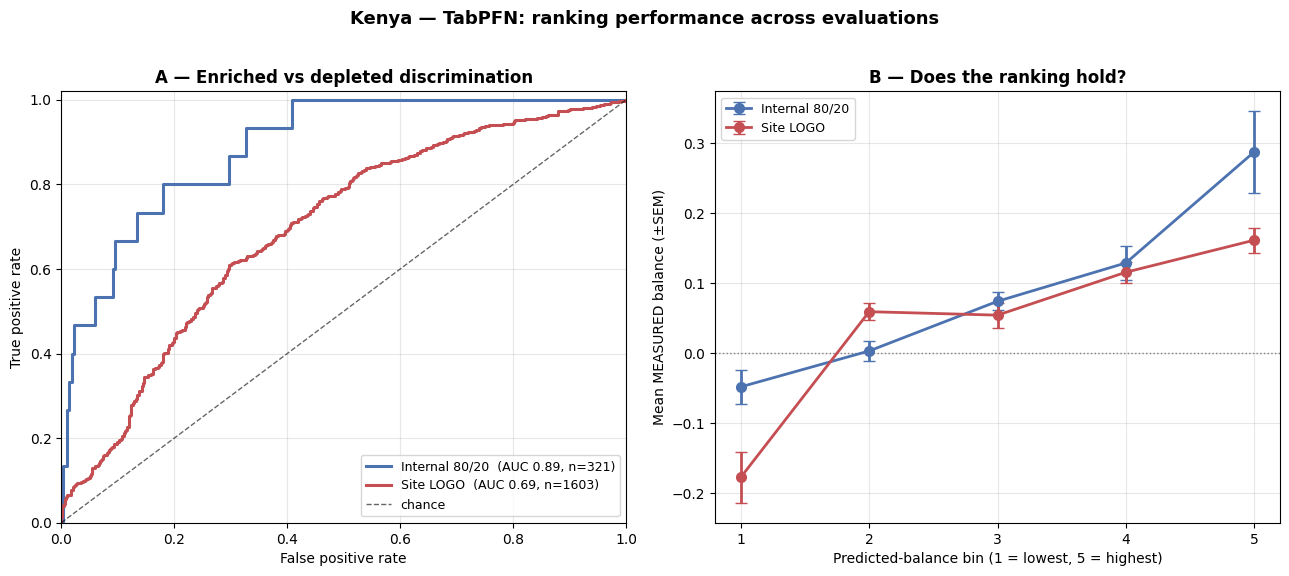

summary figure -> ./output/kenya_tabpfn_summary.png

HEADLINE TABLE
    Evaluation    n  Spearman   AUC Top 20% hit rate Base rate  Lift                   What it measures
Internal 80/20  321     0.528 0.888              17%        5%  3.68          within-site interpolation
     Site LOGO 1603     0.360 0.695              81%       69%  1.18 unseen site — transfer lower bound

headline table -> ./output/kenya_tabpfn_headline.csv

Full metrics (R2/RMSE/MAE/Pearson/MCC/bal_acc) remain in ./output/kenya_tabpfn_metrics.csv for the supplement.

SAY THIS OUT LOUD

Internal 80/20 (n=321):
  "Pick one enriched and one depleted location at random — the model ranks
   them correctly 89% of the time (a coin flip would be 50%)."
  "Of the top 20% of locations the model flags, 17% are genuinely enriched,
   against 5% if you picked at random — 3.68x better than chance."

Site LOGO (n=1603):
  "Pick one enriched and one depleted location at random — the model ranks
   them correctly 70% of the time

In [13]:
# ── SUMMARY FIGURE + HEADLINE TABLE (the one to put in the paper) ─────────
# The claim is RANKING ("which places are enriched"), not MAGNITUDE ("how
# enriched"). These two panels test exactly that, and neither invites the
# 1:1-diagonal comparison the pred-vs-true scatters do.
#   A) ROC  : does the model put samples on the correct side of the threshold?
#   B) Decile: bin by PREDICTED balance, plot mean MEASURED balance per bin.
#             A monotonic rise = ranking works.
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

assert EVALS, "No evaluations registered — run the evaluation cells first."
ORDER = ["Internal 80/20", "External validation", "Site LOGO"]
labels = [k for k in ORDER if k in EVALS] + [k for k in EVALS if k not in ORDER]
COLORS = {"Internal 80/20": "#4C72B0", "External validation": "#55A868",
          "Site LOGO": "#C44E52"}

N_BINS = 5   # deciles need ~200+ pts; 5 bins is readable for n<100 too
TOP_FRAC = 0.20   # "of the top 20% the model flags, how many are real?"

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5.6))

summary = []
for lab in labels:
    e   = EVALS[lab]
    yt, yp, thr = e["true"], e["pred"], e["thr"]
    col = COLORS.get(lab, "grey")
    cls = (yt > thr).astype(int)
    spear = spearmanr(yt, yp)[0]

    # ── A: ROC ──
    if 0 < cls.mean() < 1:
        fpr, tpr, _ = roc_curve(cls, yp)
        auc = roc_auc_score(cls, yp)
        axA.plot(fpr, tpr, color=col, lw=2.2,
                 label=f"{lab}  (AUC {auc:.2f}, n={len(yt)})")
    else:
        auc = np.nan
        print(f"  [skip ROC] {lab}: single class at thr={thr:.3f}")

    # ── B: ranking check — bin by PREDICTION, show measured mean ──
    q = pd.qcut(pd.Series(yp).rank(method="first"), N_BINS, labels=False)
    b = (pd.DataFrame({"bin": q, "meas": yt}).groupby("bin")["meas"]
         .agg(["mean", "sem", "size"]))
    axB.errorbar(b.index + 1, b["mean"], yerr=b["sem"].fillna(0),
                 marker="o", ms=7, lw=2, capsize=4, color=col, label=lab)

    # ── top-X% hit rate: the "where do I dig" number ──
    k    = max(1, int(round(TOP_FRAC * len(yp))))
    top  = np.argsort(yp)[::-1][:k]          # k highest-predicted samples
    hit  = float(cls[top].mean())            # share of those truly enriched
    base = float(cls.mean())                 # share enriched overall
    lift = hit / base if base > 0 else np.nan

    summary.append({"Evaluation": lab, "n": len(yt),
                    "Spearman": round(float(spear), 3),
                    "AUC": (round(float(auc), 3) if np.isfinite(auc) else np.nan),
                    f"Top {int(TOP_FRAC*100)}% hit rate": f"{hit:.0%}",
                    "Base rate": f"{base:.0%}",
                    "Lift": (round(lift, 2) if np.isfinite(lift) else np.nan),
                    "What it measures": e["note"]})

axA.plot([0, 1], [0, 1], "k--", lw=1, alpha=.6, label="chance")
axA.set_xlabel("False positive rate"); axA.set_ylabel("True positive rate")
axA.set_title("A — Enriched vs depleted discrimination", fontweight="bold")
axA.legend(loc="lower right", fontsize=9); axA.grid(alpha=.3)
axA.set_xlim(0, 1); axA.set_ylim(0, 1.02)

axB.axhline(0, color="grey", ls=":", lw=1)
axB.set_xlabel(f"Predicted-balance bin (1 = lowest, {N_BINS} = highest)")
axB.set_ylabel("Mean MEASURED balance (±SEM)")
axB.set_title("B — Does the ranking hold?", fontweight="bold")
axB.set_xticks(range(1, N_BINS + 1))
axB.legend(fontsize=9); axB.grid(alpha=.3)

fig.suptitle(f"{dataset.title()} — TabPFN: ranking performance across evaluations",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
os.makedirs("./output", exist_ok=True)
_fp = f"./output/{dataset}_tabpfn_summary.png"
plt.savefig(_fp, dpi=200, bbox_inches="tight"); plt.show()
print("summary figure ->", _fp)

tbl = pd.DataFrame(summary)
print("\n" + "="*72)
print("HEADLINE TABLE")
print("="*72)
print(tbl.to_string(index=False))
tbl.to_csv(f"./output/{dataset}_tabpfn_headline.csv", index=False)
print("\nheadline table -> ./output/{}_tabpfn_headline.csv".format(dataset))
print("\nFull metrics (R2/RMSE/MAE/Pearson/MCC/bal_acc) remain in "
      f"./output/{dataset}_tabpfn_metrics.csv for the supplement.")

# ── Quotable sentences for the talk ──────────────────────────────────────
print("\n" + "="*72)
print("SAY THIS OUT LOUD")
print("="*72)
for r in summary:
    if np.isfinite(r["AUC"]):
        print(f"\n{r['Evaluation']} (n={r['n']}):")
        print(f"  \"Pick one enriched and one depleted location at random — the "
              f"model ranks\n   them correctly {r['AUC']:.0%} of the time "
              f"(a coin flip would be 50%).\"")
        print(f"  \"Of the top {int(TOP_FRAC*100)}% of locations the model flags, "
              f"{r[f'Top {int(TOP_FRAC*100)}% hit rate']} are genuinely enriched,\n"
              f"   against {r['Base rate']} if you picked at random "
              f"— {r['Lift']}x better than chance.\"")


In [ ]:
import rasterio
from helpers.load_satellite_data import _add_spectral_indices, _read_band_names

def predict_raster_tabpfn(reg, satellite, feature_cols, y_lo=None, y_hi=None,
                          base="./data/satellite", mask_path=None, sharpen_swir=False,
                          batch=200000, unc_pct=95, out_path=None):
    """
    Raster inference with TabPFN. Uses RAW features (the model is trained on raw
    X — no standardization anywhere), so no (x-mu)/sd here. Predictions are
    optionally clipped to [y_lo, y_hi] to curb extrapolation.
    """
    out_path = out_path or f"./output/{dataset}_tabpfn_prediction.tif"
    with rasterio.open(f"{base}/{satellite}.tif") as src:
        prof = src.profile.copy(); img = src.read().astype("float32")
        bn = _read_band_names(satellite, base, src.count); H, W = src.height, src.width
    if sharpen_swir:
        from helpers.feature_ops import sharpen_swir_bands; img = sharpen_swir_bands(img, bn)
    B = img.shape[0]
    dfx = _add_spectral_indices(pd.DataFrame(img.reshape(B, -1).T, columns=bn), satellite)
    Xr = dfx[feature_cols].values
    valid = np.isfinite(Xr).all(1)
    if mask_path:
        with rasterio.open(mask_path) as mk:
            valid &= (mk.read(1).reshape(-1) == 1)
    idx = np.where(valid)[0]
    print(f"predicting {len(idx):,} bare-soil pixels of {Xr.shape[0]:,}")

    pred = np.full(Xr.shape[0], np.nan, "float32")
    unc  = np.full(Xr.shape[0], np.nan, "float32")
    for i in range(0, len(idx), batch):
        j = idx[i:i+batch]
        Xb = Xr[j]                                   # raw features (as trained)
        pred[j] = reg.predict(Xb)
        lo, med, hi = reg.predict(Xb, output_type="quantiles", quantiles=[0.05, 0.5, 0.95])
        unc[j] = hi - lo
        print(f"  {min(i+batch, len(idx)):,}/{len(idx):,}")

    if y_lo is not None and y_hi is not None:      # clip to training range
        pred = np.where(np.isfinite(pred), np.clip(pred, y_lo, y_hi), np.nan).astype("float32")
    # (the old uncertainty "mask" only printed a threshold and never applied it
    #  -> removed. Uncertainty is still written to *_uncertainty.tif for QGIS.)

    prof.update(count=1, dtype="float32", nodata=np.nan, compress="lzw")
    os.makedirs("./output", exist_ok=True)
    def _w(arr, path):
        with rasterio.open(path, "w", **prof) as d: d.write(arr.reshape(H, W), 1)
    _w(pred, out_path)
    _w(unc, out_path.replace(".tif", "_uncertainty.tif"))

    return out_path

# ── Bare-soil mask toggle ────────────────────────────────────────────────
# True  -> predict only on bare-soil pixels (black blobs in QGIS). This is the
#          REPORTED product: the model only ever saw bare-soil samples, so
#          off-mask pixels are extrapolation.
# False -> predict everywhere (continuous map, no blobs). Good for LOOKING at,
#          NOT for reporting: vegetated/shadow pixels are out of training domain.
MASK_PREDICTION = False

# Clip predictions to the observed training-balance range (curbs wild extrapolation).
Y_LO, Y_HI = float(np.min(y)), float(np.max(y))
_suffix   = "" if MASK_PREDICTION else "_nomask"
PRED_PATH = f"./output/{dataset}_tabpfn_prediction{_suffix}.tif"
predict_raster_tabpfn(
    reg_full, satellite, feature_cols, y_lo=Y_LO, y_hi=Y_HI,
    mask_path=(f"./output/baresoil_mask_{dataset}.tif" if MASK_PREDICTION else None),
    sharpen_swir=SHARPEN_SWIR, out_path=PRED_PATH)
print(f"{'MASKED' if MASK_PREDICTION else 'UNMASKED'} prediction -> {PRED_PATH}")
if not MASK_PREDICTION:
    print("  NOTE: off-mask pixels are OUTSIDE the training domain "
          "(model saw bare soil only). Use for visualisation, not for reporting.")